# Projeto de ML: Previsão de "No-Shows" em Consultas

**Objetivo:** Construir e avaliar uma rede neural (MLP) para prever a probabilidade de um paciente faltar a uma consulta médica, usando a base de dados pública de Vitória, ES.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- CARREGAR OS DADOS ---
# Usamos '..' para "voltar" uma pasta e entrar na pasta 'data'
caminho_dados = '../data/medical_appointments.csv'
df = pd.read_csv(caminho_dados)

print("--- Dados Carregados ---")
df.head()

In [ ]:
# CÉLULA 3 (Versão FINAL e à Prova de Erros)

print("--- Iniciando Limpeza e Pré-processamento ---")

# 1. Renomear colunas
df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'No-show': 'NoShow'
}, inplace=True)

# --- Mapeamento Seguro (Evita o erro de re-execução) ---

# 2. Converter a variável ALVO (NoShow) para numérico
# SÓ executa o map SE a coluna for do tipo 'object' (texto)
if df['NoShow'].dtype == 'object':
    df['NoShow'] = df['NoShow'].map({'No': 0, 'Yes': 1})
    print("Coluna 'NoShow' mapeada.")

# 3. Converter 'Gender' para numérico
# SÓ executa o map SE a coluna for do tipo 'object' (texto)
if df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})
    print("Coluna 'Gender' mapeada.")


# 4. Engenharia de Features de Data (Correção do .normalize)
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.tz_localize(None)
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.tz_localize(None)
df['ScheduledDay_Date'] = df['ScheduledDay'].dt.normalize()
df['AppointmentDay_Date'] = df['AppointmentDay'].dt.normalize()

df['WaitingDays'] = (df['AppointmentDay_Date'] - df['ScheduledDay_Date']).dt.days
df['WaitingDays'] = df['WaitingDays'].apply(lambda x: 0 if x < 0 else x)

# 5. Criar features de Dia da Semana
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.dayofweek

# 6. Seleção Final de Features
features_selecionadas = [
    'Gender',
    'Age',
    'Scholarship',
    'Hypertension',
    'Diabetes',
    'Alcoholism',
    'Handicap',
    'SMS_received',
    'WaitingDays',
    'AppointmentDayOfWeek'
]
target = 'NoShow'

df_limpo = df[features_selecionadas + [target]].copy()

# --- Limpeza Final ---
# Agora podemos apagar com segurança, pois as colunas mapeadas
# não devem ter nulos. Isso só vai apagar nulos que 
# por acaso existiam no dataset original.
print(f"\nNulos antes do dropna: {df_limpo.isnull().sum().sum()}")
df_limpo.dropna(inplace=True)

print("\n--- DataFrame Limpo e Pronto para o Modelo ---")
print(f"Formato final: {df_limpo.shape}")
print(df_limpo.head())

In [ ]:
# Verificar o desbalanceamento das classes
print("--- Balanceamento das Classes ---")
print(df_limpo['NoShow'].value_counts(normalize=True))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Separar Features (X) e Alvo (y) ---
# X são todas as colunas de features
X = df_limpo.drop('NoShow', axis=1)
# y é apenas a coluna alvo que queremos prever
y = df_limpo['NoShow']

print(f"Formato de X (features): {X.shape}")
print(f"Formato de y (alvo): {y.shape}")

# --- 2. Dividir em Treino e Teste ---
# test_size=0.2 significa 20% dos dados para teste
# stratify=y garante que a proporção de 20% de 'NoShow' seja mantida
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

# --- 3. Normalização dos Dados (Obrigatório para Redes Neurais) ---
scaler = StandardScaler()

# APLICAMOS 'fit_transform' NO TREINO: 
# Ele "aprende" a média e o desvio padrão dos dados de treino e os transforma
X_train_scaled = scaler.fit_transform(X_train)

# APLICAMOS APENAS 'transform' NO TESTE:
# Usamos a média e o desvio do TREINO para transformar os dados de teste.
# Isso evita "vazamento de dados" (data leakage) do teste para o treino.
X_test_scaled = scaler.transform(X_test)

print("\n--- Dados Prontos ---")
print("Dados de treino normalizados (primeira linha):")
print(X_train_scaled[0])

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# --- 1. Definir a Arquitetura da Rede (MLP) ---
model = Sequential()

# Camada de Entrada (input_shape precisa ser o número de features: 10)
# 'relu' é a função de ativação mais comum e eficiente
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Camada Oculta (para "pensar" mais)
model.add(Dense(16, activation='relu'))

# CAMADA DE SAÍDA
# 1 neurônio: porque a resposta é binária (0 ou 1)
# 'sigmoid': espreme a saída para ser uma probabilidade (entre 0.0 e 1.0)
model.add(Dense(1, activation='sigmoid'))

# Mostra um resumo da arquitetura que criamos
model.summary()

# --- 2. Compilar o Modelo ---
# 'adam': Um otimizador eficiente que "ajuda" o modelo a aprender
# 'binary_crossentropy': A função de perda correta para classificação binária
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']) # Pedimos para ele monitorar a acurácia

# --- 3. Treinar o Modelo ---
print("\n--- Iniciando o Treinamento da Rede Neural ---")

# epochs=10: O modelo vai "ler" todos os dados de treino 10 vezes
# batch_size=32: Ele vai atualizar os pesos a cada 32 amostras
# validation_data: Ele vai testar o modelo nos dados de teste a cada época
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1 # Mostra a barra de progresso
)

print("--- Treinamento Concluído ---")

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Fazer as Predições ---
# O modelo 'model.predict' retorna probabilidades (ex: 0.15, 0.82)
y_pred_proba = model.predict(X_test_scaled)

# Convertemos as probabilidades em classes (0 ou 1)
# Se a probabilidade for > 0.5, consideramos "1" (Faltou)
y_pred = (y_pred_proba > 0.5).astype("int32")

# --- 2. Gerar a Matriz de Confusão ---
# A matriz mostra os Verdadeiros Positivos, Falsos Positivos, etc.
print("--- Matriz de Confusão ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# --- 3. Gerar o Relatório de Classificação ---
# Este é o relatório mais importante!
# target_names = ['Compareceu (0)', 'Faltou (1)']
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Compareceu (0)', 'Faltou (1)']))

691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- Matriz de Confusão ---
[[17600    42]
 [ 4411    53]]

--- Relatório de Classificação ---
                precision    recall  f1-score   support

Compareceu (0)       0.80      1.00      0.89     17642
    Faltou (1)       0.56      0.01      0.02      4464

      accuracy                           0.80     22106
     macro avg       0.68      0.50      0.46     22106
  weighted avg       0.75      0.80      0.71     22106



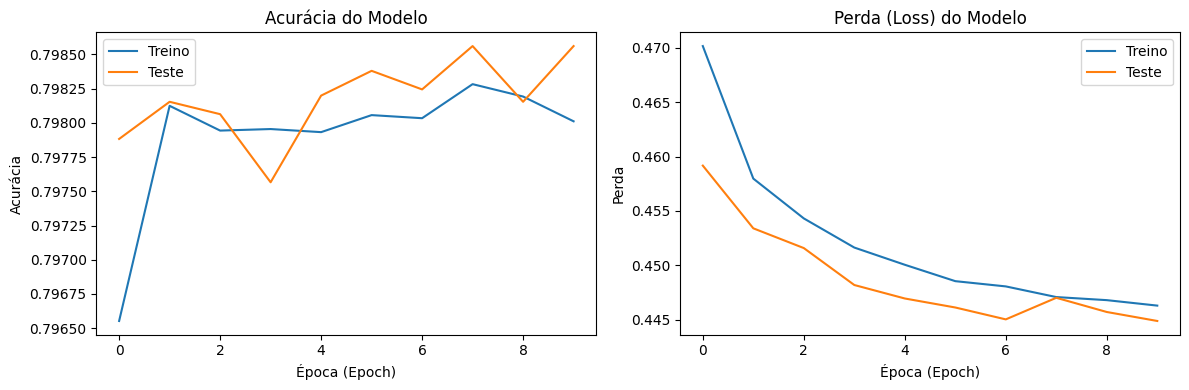

In [15]:
import matplotlib.pyplot as plt

# --- Resumo do Histórico para Acurácia ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Acurácia do Modelo')
plt.ylabel('Acurácia')
plt.xlabel('Época (Epoch)')
plt.legend(['Treino', 'Teste'], loc='upper left')

# --- Resumo do Histórico para Perda (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Perda (Loss) do Modelo')
plt.ylabel('Perda')
plt.xlabel('Época (Epoch)')
plt.legend(['Treino', 'Teste'], loc='upper right')

plt.tight_layout() # Ajusta o layout
plt.show()